### Cyclogram

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.neighbors import KernelDensity

In [2]:
# Specify path to csv for analysis
data_cyclogram = pd.read_csv('/home/svs/Workdir/gestures/gestures/notebooks/out_gyro/clean_test/shoulder_press.2.csv')

In [3]:
def plot_cyclogram(data):
    """
    Plot cyclogram of gait data using PCA.

    Args:
        data (pd.DataFrame): Data containing timestamp, acceleration and gyroscope data.
    """
    # Extract acceleration data
    acceleration_data = data[['ax', 'ay', 'az', 'gx', 'gy', 'gz', 'q0', 'q1', 'q2', 'q3']].values
    
    # Determine the size of each segment
    n = acceleration_data.shape[0]
    segment_size = n // 4

    # Create a figure with 4 subplots
    fig, axs = plt.subplots(2, 2, figsize=(18, 14))

    for i in range(4):
        # Extract the segment of data
        start_idx = i * segment_size
        if i < 3:
            end_idx = (i + 1) * segment_size
        else:
            end_idx = n  # Ensure the last segment goes to the end of the dataframe

        segment_data = acceleration_data[start_idx:end_idx]

        # Perform PCA
        pca = PCA(n_components=2)
        pca_result = pca.fit_transform(segment_data)

        # Threshold filtering: select significant contributions
        significant_mask = (np.abs(pca_result[:, 0]) > 0.8) & (np.abs(pca_result[:, 1]) > 0.8)
        pca_filtered = pca_result[significant_mask]

        # Kernel Density Estimation (KDE)
        kde = KernelDensity(kernel='gaussian', bandwidth=0.5).fit(pca_filtered)
        log_density = kde.score_samples(pca_filtered)
        density = np.exp(log_density)


        # Plotting in the appropriate subplot
        ax = axs[i // 2, i % 2]
        ax.scatter(pca_result[:, 0], pca_result[:, 1], label='Data', alpha=0.6, edgecolors='w', s=100)
        ax.plot(pca_result[:, 0], pca_result[:, 1], color='m')

        ax.set_xlabel('PCA Component 1')
        ax.set_ylabel('PCA Component 2')
        ax.set_title(f'Cyclogram for Segment {i+1}')
        ax.legend()
        ax.grid(True)

    plt.tight_layout()
    plt.show()

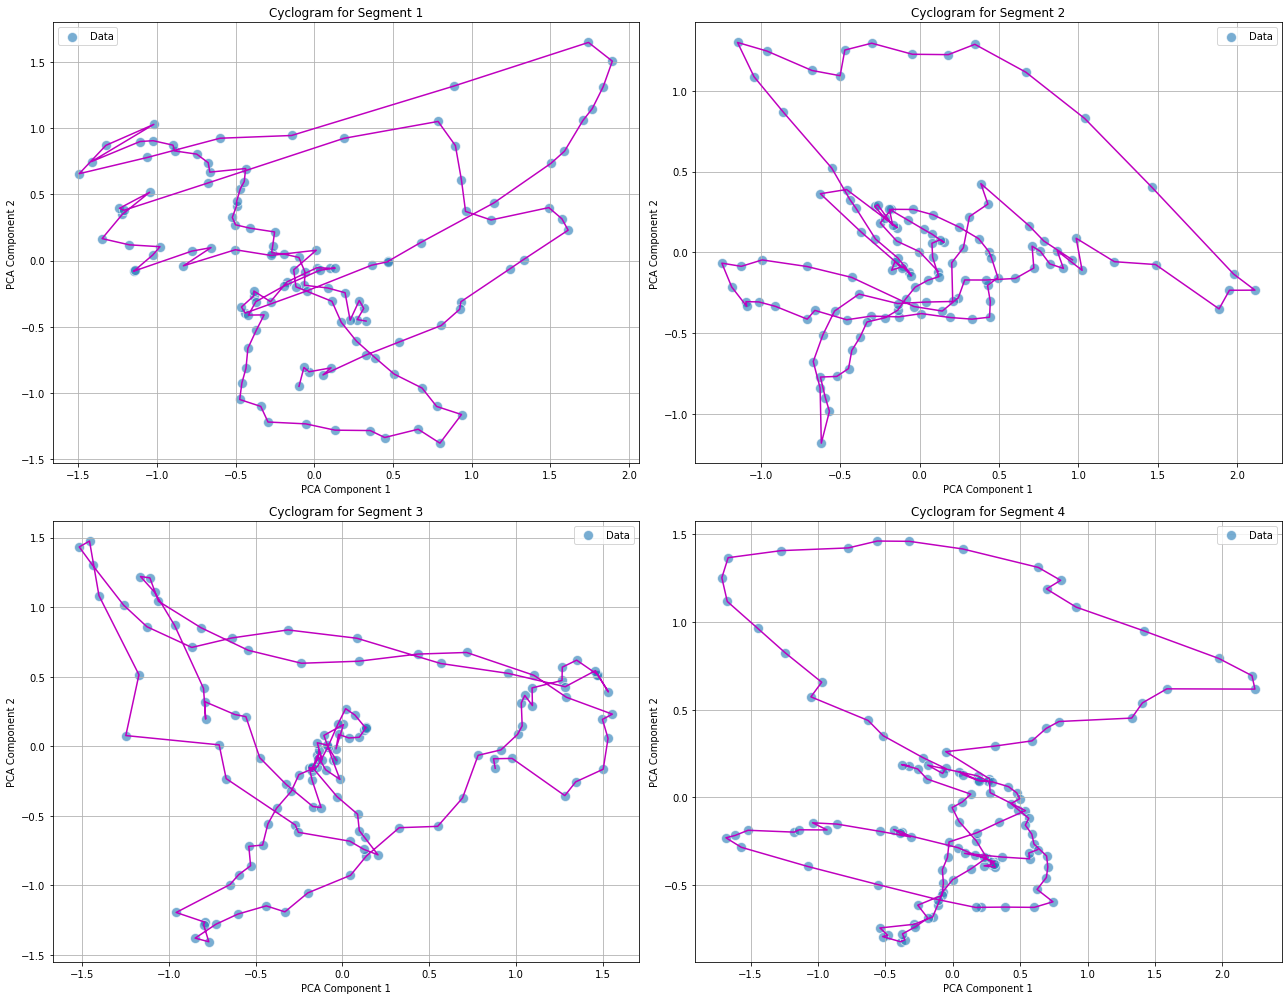

In [4]:
plot_cyclogram(data_cyclogram)